In [2]:
import pandas as pd
from pathlib import Path

folder = Path("ALLDataGross/healthyCohort")
dataframes = []

for file in sorted(folder.glob("*.dpt")):
    try:
        # whitespace flexible (tabs or spaces)
        df = pd.read_csv(file, sep=r"\s+", engine="python")
        if df.shape[1] != 2:
            df = pd.read_csv(file, sep=r",", engine="python")
        dataframes.append((file.stem, df))
        print(f"✅ Loaded {file.name} with {df.shape[1]} columns")
        df.columns = ["Wavenumber", "Intensity"]
    except Exception as e:
        print(f"❌ Error loading {file.name}: {e}")


✅ Loaded 20171109-01-EL-TB-8y.01.dpt with 2 columns
✅ Loaded 20171109-02-PL-TB-5y.02.dpt with 2 columns
✅ Loaded 20171109-04-OG-TB-M1.04.dpt with 2 columns
✅ Loaded 20171109-06-TA-TB-M1.06.dpt with 2 columns
✅ Loaded 20171109-16-AL-TB-M1.16.dpt with 2 columns
✅ Loaded 20171109-17-AH-TB-M1.17.dpt with 2 columns
✅ Loaded 20171109-22-SR-TB-M1.22.dpt with 2 columns
✅ Loaded 20171109-26-ML-TB-M1.26.dpt with 2 columns
✅ Loaded 20171123-04-KM-TB.dpt with 2 columns
✅ Loaded 20171123-18-AA-ExD.dpt with 2 columns
✅ Loaded 20180125-22-TS-TB.dpt with 2 columns
✅ Loaded 20180205-01-OL-TB.dpt with 2 columns
✅ Loaded 20180205-16-CW-TB.16.dpt with 2 columns
✅ Loaded 20180205-17-MG-TB.17.dpt with 2 columns
✅ Loaded 20180802-05-MF-TB.dpt with 2 columns
✅ Loaded 20190312-12-EF-DB.dpt with 2 columns
✅ Loaded 20190405-02-001.dpt with 2 columns
✅ Loaded 20190405-05-004.dpt with 2 columns
✅ Loaded 20190606-07-015.dpt with 2 columns
✅ Loaded 20190606-08-016.dpt with 2 columns
✅ Loaded 20190606-14-CR-TB.dpt wi

In [3]:
import numpy as np

def find_quiet_region(x, y, window_size=50, step=10):
    """
    Find spectral regions with minimal absorption (flat baseline).
    
    Parameters
    ----------
    x : array
        Wavenumbers (must be sorted increasing or decreasing).
    y : array
        Absorbance values.
    window_size : int
        Width of window in cm^-1.
    step : int
        Step size for scanning (cm^-1).
    
    Returns
    -------
    best_region : tuple
        (lo, hi) wavenumber range of flattest region.
    score : float
        Standard deviation of intensity in that region.
    """
    # Ensure ascending order
    if x[0] > x[-1]:
        x, y = x[::-1], y[::-1]

    best_score = np.inf
    best_region = None

    xmin, xmax = x.min(), x.max()
    centers = np.arange(xmin + window_size/2, xmax - window_size/2, step)

    for c in centers:
        lo, hi = c - window_size/2, c + window_size/2
        mask = (x >= lo) & (x <= hi)
        if mask.sum() < 5:
            continue
        region_std = np.std(y[mask])
        if region_std < best_score:
            best_score = region_std
            best_region = (lo, hi)

    return best_region, best_score

filename, df = dataframes[0]
x = df['Wavenumber'].values
y = df['Intensity'].values
# Example usage
best_region, score = find_quiet_region(x, y, window_size=50, step=20)
print("Best flat region:", best_region, "with std =", score)


Best flat region: (np.float64(2540.02857), np.float64(2590.02857)) with std = 5.468658779824191e-05


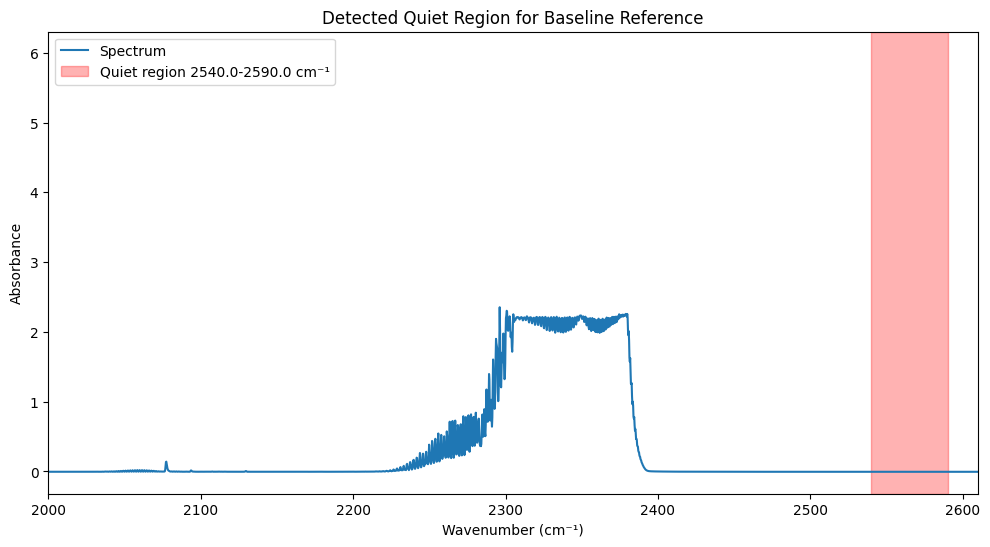

Best flat region: (np.float64(2540.02857), np.float64(2590.02857)) with std = 5.468658779824191e-05


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def find_quiet_region(x, y, window_size=50, step=10, plot=True):
    """
    Find spectral regions with minimal absorption (flat baseline).
    Optionally plot the region.
    """
    # Ensure ascending order
    if x[0] > x[-1]:
        x, y = x[::-1], y[::-1]

    best_score = np.inf
    best_region = None

    xmin, xmax = x.min(), x.max()
    centers = np.arange(xmin + window_size/2, xmax - window_size/2, step)

    for c in centers:
        lo, hi = c - window_size/2, c + window_size/2
        mask = (x >= lo) & (x <= hi)
        if mask.sum() < 5:
            continue
        region_std = np.std(y[mask])
        if region_std < best_score:
            best_score = region_std
            best_region = (lo, hi)

    if plot and best_region:
        lo, hi = best_region
        mask = (x >= lo) & (x <= hi)

        plt.figure(figsize=(12,6))
        plt.plot(x, y, label="Spectrum")
        plt.axvspan(lo, hi, color='red', alpha=0.3, label=f"Quiet region {lo:.1f}-{hi:.1f} cm⁻¹")
        # plt.gca().invert_xaxis()
        plt.xlim(2000, 2610)
        plt.xlabel("Wavenumber (cm⁻¹)")
        plt.ylabel("Absorbance")
        plt.legend()
        plt.title("Detected Quiet Region for Baseline Reference")
        plt.show()

    return best_region, best_score

# Example usage
best_region, score = find_quiet_region(x, y, window_size=50, step=20, plot=True)
print("Best flat region:", best_region, "with std =", score)


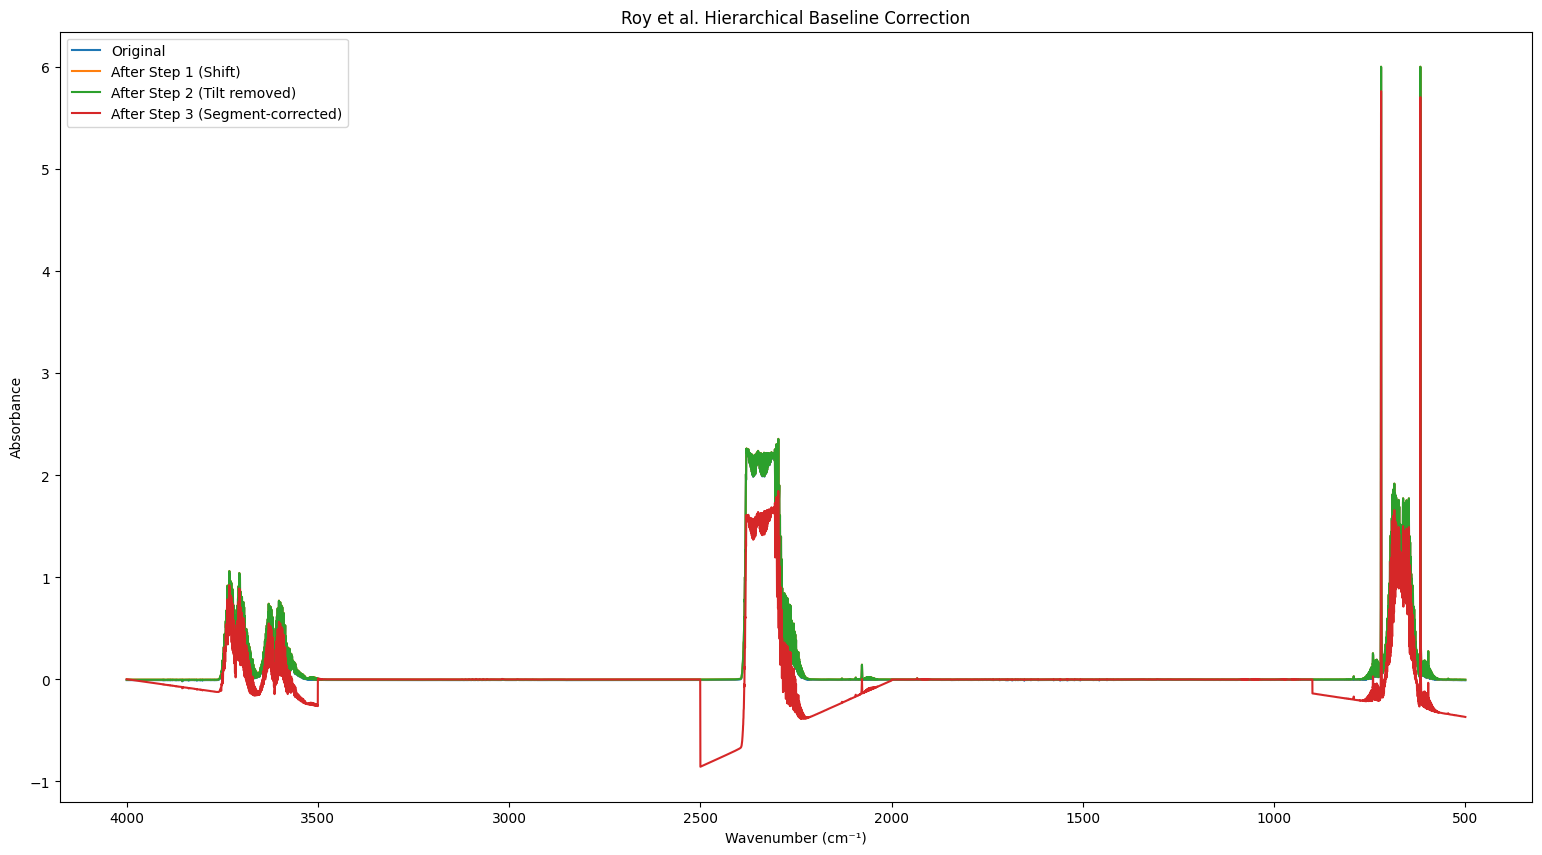

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def baseline_roy(x, y, 
                 ref_region=(2540, 2590), 
                 segment_edges=None):
    """
    Hierarchical baseline correction per Roy & Maiti (2024).
    1. Linear shift based on region.
    2. Remove global linear tilt.
    3. Remove local tilt per segment.
    """

    # Ensure numpy arrays & sorted wavenumbers
    x = np.array(x, float)
    y = np.array(y, float)
    if x[0] > x[-1]:
        x, y = x[::-1], y[::-1]

    # 1. First-order shift using ref_region
    lo, hi = ref_region
    mask_ref = (x >= lo) & (x <= hi)
    if not mask_ref.any():
        shift = 0.0
    else:
        shift = np.mean(y[mask_ref])
    y1 = y - shift

    # 2. Second-order: remove global linear tilt
    N = len(y1)
    slope = (y1[-1] - y1[0]) / (N - 1)
    trend = slope * np.arange(N)
    y2 = y1 - trend

    # 3. Third-order: segment-wise correction
    if segment_edges is None:
        # Default segments: 500 segments over full range
        segment_edges = np.linspace(x.min(), x.max(), 11)  # 10 segments
    y3 = y2.copy()
    for i in range(len(segment_edges)-1):
        loe, hie = segment_edges[i], segment_edges[i+1]
        mask = (x >= loe) & (x < hie)
        if mask.sum() < 2:
            continue
        xi = x[mask]; yi = y2[mask]
        # linear detrend within segment
        m, b = np.polyfit(xi, yi, 1)
        y3[mask] = yi - (m * xi + b)

    return y3, y1, y2  # return all stages for QC

# Example usage
segment_edges = [500, 900, 1500, 2000, 2500, 3000, 3500, 4000]
y_stage3, y_stage1, y_stage2 = baseline_roy(x, y, ref_region=(2550,2600), segment_edges=segment_edges)

# visualize
plt.figure(figsize=(19,10))
plt.plot(x, y, label='Original')
plt.plot(x, y_stage1, label='After Step 1 (Shift)')
plt.plot(x, y_stage2, label='After Step 2 (Tilt removed)')
plt.plot(x, y_stage3, label='After Step 3 (Segment-corrected)')
plt.gca().invert_xaxis()
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Absorbance")
plt.legend(); plt.title("Roy et al. Hierarchical Baseline Correction")
plt.show()


In [6]:
def evaluate_baseline(x, y, stage_name, 
                      quiet_region=(2550,2600), 
                      peak_region=(2350,2400), 
                      noise_region=(2000,2200)):
    """
    Compute QC metrics for baseline correction stage.
    """
    def region_mask(rng):
        lo, hi = rng
        return (x >= lo) & (x <= hi)

    # quiet region stats
    qmask = region_mask(quiet_region)
    quiet_mean = np.mean(y[qmask])
    quiet_std = np.std(y[qmask])

    # noise region stats
    nmask = region_mask(noise_region)
    noise_std = np.std(y[nmask])

    # peak stats
    pmask = region_mask(peak_region)
    peak_height = np.max(y[pmask]) - np.min(y[pmask])
    peak_area = np.trapz(y[pmask], x[pmask])

    print(f"=== {stage_name} ===")
    print(f" Quiet region mean: {quiet_mean:.4g}, std: {quiet_std:.4g}")
    print(f" Noise std: {noise_std:.4g}")
    print(f" Peak {peak_region} height: {peak_height:.4g}, area: {peak_area:.4g}")
    print()

    return {
        "stage": stage_name,
        "quiet_mean": quiet_mean,
        "quiet_std": quiet_std,
        "noise_std": noise_std,
        "peak_height": peak_height,
        "peak_area": peak_area
    }

# Example workflow:
y_stage3, y_stage1, y_stage2 = baseline_roy(x, y)

metrics_raw   = evaluate_baseline(x, y, "Raw")
metrics_s1    = evaluate_baseline(x, y_stage1, "Stage 1 (Shift)")
metrics_s2    = evaluate_baseline(x, y_stage2, "Stage 2 (Tilt removed)")
metrics_s3    = evaluate_baseline(x, y_stage3, "Stage 3 (Segment corrected)")


=== Raw ===
 Quiet region mean: -0.005524, std: 5.572e-05
 Noise std: 0.009845
 Peak (2350, 2400) height: 2.258, area: 72.39

=== Stage 1 (Shift) ===
 Quiet region mean: 1.71e-06, std: 5.572e-05
 Noise std: 0.009845
 Peak (2350, 2400) height: 2.258, area: 72.66

=== Stage 2 (Tilt removed) ===
 Quiet region mean: -0.0008995, std: 5.695e-05
 Noise std: 0.009849
 Peak (2350, 2400) height: 2.258, area: 72.62

=== Stage 3 (Segment corrected) ===
 Quiet region mean: 0.2119, std: 0.08021
 Noise std: 0.01195
 Peak (2350, 2400) height: 2.175, area: 28.78



/tmp/ipykernel_15135/3260406362.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  peak_area = np.trapz(y[pmask], x[pmask])


Third stage (piecewise baseline fitting) is too aggressive in this case.
It is flattening not just the baseline, but also eating into real peaks (especially broad CO₂ bands).
That’s why the area dropped by ~60%.
Noise std also increased (0.009 → 0.012).
So in practice, Stage 3 may harm more than help for IR breath spectra in THIS case, unless:

1. segment carefully (avoid peak-rich regions).
2. You anchor the baseline using only validated “quiet regions”.

In [7]:
def reanchor_baseline(x, y, quiet_region=(2550,2600)):
    mask = (x >= quiet_region[0]) & (x <= quiet_region[1])
    shift = np.mean(y[mask])
    return y - shift

# Example:
y_stage3_fixed = reanchor_baseline(x, y_stage3)
evaluate_baseline(x, y_stage3_fixed, "Stage 3 (Re-anchored)")


=== Stage 3 (Re-anchored) ===
 Quiet region mean: -8.54e-18, std: 0.08021
 Noise std: 0.01195
 Peak (2350, 2400) height: 2.175, area: 18.25



/tmp/ipykernel_15135/3260406362.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  peak_area = np.trapz(y[pmask], x[pmask])


{'stage': 'Stage 3 (Re-anchored)',
 'quiet_mean': np.float64(-8.540177112501205e-18),
 'quiet_std': np.float64(0.08020533571330729),
 'noise_std': np.float64(0.011950099712317813),
 'peak_height': np.float64(2.1748749535194927),
 'peak_area': np.float64(18.251614671737904)}